In [ ]:
from kkcalc2 import kk_transforms as kkt, conversions as kkc
import numpy as np
import matplotlib.pyplot as plt

# Create some base functions, with a domain

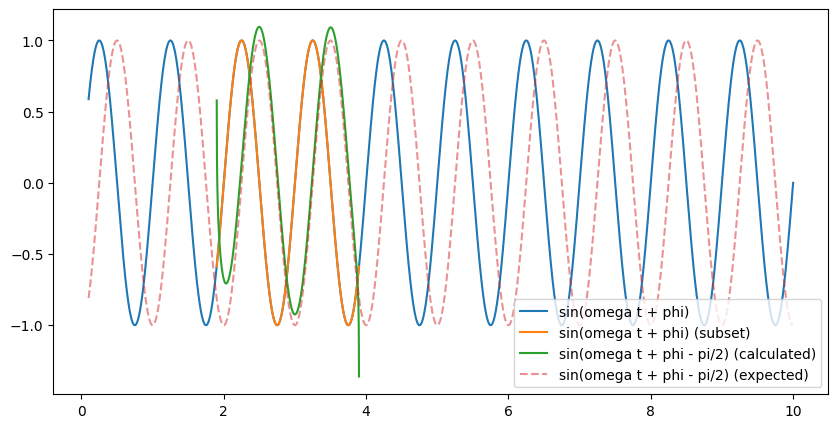

In [2]:
# Table item 1 : sin(omega t + phi) -> sin(omega t + phi - pi/2)
omega = 1 * 2 * np.pi  # 1Hz
x1 = np.linspace(0.1, 10, 20000)  # t
f1 = np.sin(omega * x1)
# Take a subset of the data
idx = ((4 * np.pi / omega - x1[0] * 2 * np.pi / omega) < x1) & (
    x1 < (8 * np.pi / omega - x1[0] * 2 * np.pi / omega)
)
# idx[0] = True # add endpoints
# idx[-1] = True # add endpoints
x1_sub = x1[idx]
f1_sub = f1[idx]
# Convert to polynomial
f1_poly = kkc.conversions.ASF_to_ASP(x1_sub, f1_sub)
# Result
r1 = kkt.KK_PP(x1_sub, x1_sub, f1_poly, 0)
e1 = np.sin(omega * x1 - np.pi / 2)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(x1, f1, label="sin(omega t + phi)")
ax.plot(x1_sub, f1_sub, label="sin(omega t + phi) (subset)")
ax.plot(x1_sub, r1, label="sin(omega t + phi - pi/2) (calculated)")
ax.plot(x1, e1, label="sin(omega t + phi - pi/2) (expected)", linestyle="--", alpha=0.5)
# ax.set_xlim(0, 1)
ax.legend()
# ax.set_xlim(19.5, 21.5)

In [29]:
r1

array([nan, nan, nan, ..., nan, nan, nan])

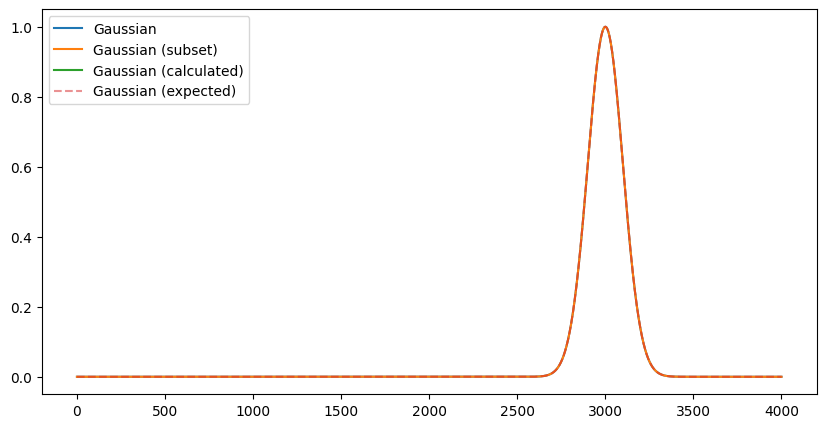

In [64]:
def gauss(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)


# Table item 2 : Gaussian -> Gaussian
x2 = np.linspace(0, 4000, 20000)
mu = 3000
sigma = 100
f2 = gauss(x2, mu, sigma)
# Take a subset of the data
idx = (2500 < x2) & (x2 < 3500)
idx[0] = True  # add endpoints
idx[-1] = True  # add endpoints
x2_sub = x2[idx]
f2_sub = f2[idx]
# Convert to polynomial
f2_poly = kkc.conversions.ASF_to_ASP(x2_sub, f2_sub)
# Result
r2 = kkt.KK_PP(x2_sub, x2_sub, f2_poly, 0)
e2 = gauss(x2, mu, sigma)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(x2, f2, label="Gaussian")
ax.plot(x2_sub, f2_sub, label="Gaussian (subset)")
ax.plot(x2_sub, r2, label="Gaussian (calculated)")
ax.plot(x2, e2, label="Gaussian (expected)", linestyle="--", alpha=0.5)
# ax.set_xlim(0, 1)
ax.legend()
# ax.set_xlim(2900, 3100)